<a href="https://colab.research.google.com/github/ambgeo/Youtube/blob/main/10_GEOBR_GEOPANDAS.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
##instale Geobr
!pip install geobr -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 338.0/338.0 kB 6.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.0/5.0 MB 58.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.1/3.1 MB 84.5 MB/s eta 0:00:00


In [2]:
##import as bibliotecas
import geobr
import geopandas as gpd
import matplotlib.pyplot as plt

In [3]:
# 1. Definir o município e o ano de interesse
nome_municipio = "Campinas"
uf_municipio = "SP"
ano = 2020

print(f"Baixando dados para {nome_municipio}...")

Baixando dados para Campinas...


In [4]:

# 2. Baixar a malha geográfica do município específico
# O geobr permite buscar pelo nome ou código, mas é bom ter o código IBGE ou filtrar depois
# Aqui baixamos 'all' de SP e filtramos pelo nome para garantir
municipios = geobr.read_municipality(code_muni='SP', year=ano, simplified=True)
municipio_alvo = municipios[municipios['name_muni'] == nome_municipio]

# 3. Baixar os pontos de todas as escolas do Brasil (Censo Escolar)
# A função read_schools retorna um GeoDataFrame
print("Baixando dados das escolas (isso pode demorar um pouco)...")
escolas = geobr.read_schools(year=ano)

Baixando dados das escolas (isso pode demorar um pouco)...


In [11]:
# 4. Filtrar as escolas apenas para o município desejado
# A coluna 'name_muni' contém o nome do município na base de escolas
escolas_filtradas = escolas[escolas['name_muni'] == nome_municipio]

# 5. Contar o número de escolas
num_escolas = len(escolas_filtradas)
print(f"Total de escolas encontradas em {nome_municipio}: {num_escolas}")

Total de escolas encontradas em Campinas: 743


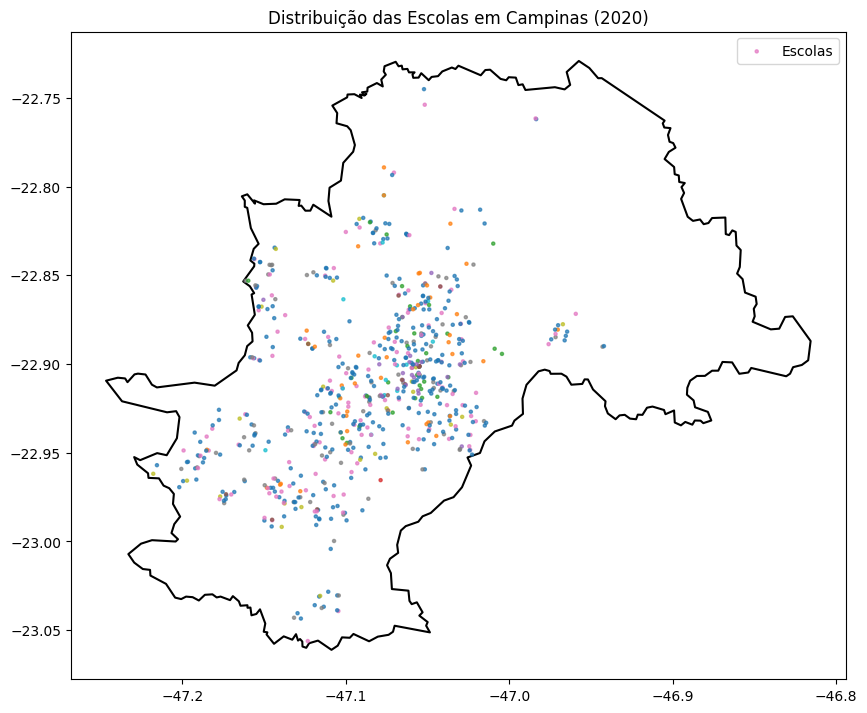

In [17]:
# --- Visualização ---
fig, ax = plt.subplots(figsize=(10, 10))

# Plota o contorno do município
municipio_alvo.plot(ax=ax, facecolor='none', edgecolor='black', linewidth=1.5)

# Plota as escolas como pontos
escolas_filtradas.plot(ax=ax, column='education_level', markersize=5, alpha=0.7, label='Escolas')

plt.title(f"Distribuição das Escolas em {nome_municipio} ({ano})")
plt.legend()
plt.show()
